## **Libraries Imported**

In [14]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


# Data Cleaning

In [36]:
DATA_PATH = Path("enhanced_student_habits_performance_dataset.csv")
print(df.columns)
def load_clean_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    df = df.drop_duplicates()

    if "student_id" in df.columns:
        df = df.drop_duplicates(subset=["student_id"])

    rename_map = {
        "sleep_hours": "hours_slept",
        "exam_score": "grade",
        "major": "subject",
    }
    df = df.rename(columns=rename_map)

    required_columns = ["student_id", "hours_slept", "grade", "subject"]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    numeric_columns = [
        "age",
        "study_hours_per_day",
        "social_media_hours",
        "netflix_hours",
        "attendance_percentage",
        "hours_slept",
        "exercise_frequency",
        "mental_health_rating",
        "previous_gpa",
        "semester",
        "stress_level",
        "social_activity",
        "screen_time",
        "parental_support_level",
        "motivation_level",
        "exam_anxiety_score",
        "time_management_score",
        "grade",
    ]

    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
            df[column] = df[column].fillna(df[column].median())

    categorical_columns = [column for column in df.columns if column not in numeric_columns]
    for column in categorical_columns:
        df[column] = df[column].astype("string").str.strip()
        df[column] = df[column].replace({"": pd.NA, "nan": pd.NA})
        mode = df[column].mode(dropna=True)
        if not mode.empty:
            df[column] = df[column].fillna(mode.iloc[0])
        else:
            df[column] = df[column].fillna("Unknown")

    if "subject" in df.columns:
        df["subject"] = df["subject"].str.title()
    if "gender" in df.columns:
        df["gender"] = df["gender"].str.title()
    if "extracurricular_participation" in df.columns:
        df["extracurricular_participation"] = df["extracurricular_participation"].str.title()

    bounds = {
        "hours_slept": (0, 24),
        "study_hours_per_day": (0, 24),
        "attendance_percentage": (0, 100),
        "stress_level": (1, 10),
        "previous_gpa": (0, 4),
        "grade": (0, 100),
        "age": (15, 35),
    }

    valid_rows = pd.Series(True, index=df.index)
    for column, (low, high) in bounds.items():
        if column in df.columns:
            valid_rows &= df[column].between(low, high)

    df = df.loc[valid_rows].copy()

    df["total_score"] = df["grade"]
    df["average_score"] = df["grade"]
    df["study_sleep_ratio"] = (
        df["study_hours_per_day"] / df["hours_slept"].replace(0, np.nan)
    ).fillna(0)
    df["sleep_stress_balance"] = df["hours_slept"] - df["stress_level"]

    return df


df = load_clean_data(DATA_PATH)
print(f"Cleaned dataset shape: {df.shape}")
df.head()

Index(['student_id', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'hours_slept', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'previous_gpa', 'semester', 'stress_level', 'dropout_risk',
       'social_activity', 'screen_time', 'study_environment',
       'access_to_tutoring', 'family_income_range', 'parental_support_level',
       'motivation_level', 'exam_anxiety_score', 'learning_style',
       'time_management_score', 'grade', 'total_score', 'average_score',
       'study_sleep_ratio', 'sleep_stress_balance', 'age_17', 'age_18',
       'age_19', 'age_20', 'age_21', 'age_22', 'age_23', 'age_24', 'age_25',
       'age_26', 'age_27', 'age_28', 'gender_Male', 'gender_Other',
       'extracurricular_participation_Yes', 'subject_Biology',
       'subject_Business', 'subject_Computer Science', 'subject_Engineering',
       'subject_Psycholo

,student_id,age,gender,subject,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,hours_slept,...,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,grade,total_score,average_score,study_sleep_ratio,sleep_stress_balance
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,9,7,8,Reading,3.0,100,100,100,1.233124,0.4
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,7,2,10,Reading,6.0,99,99,99,0.791667,1.4
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,3,9,6,Kinesthetic,7.6,98,98,98,0.260870,1.2
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,5,3,10,Reading,3.2,100,100,100,0.809524,-0.4
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9,1,10,Reading,7.1,98,98,98,0.723077,0.8


# Encode Categorical Variables

In [17]:
df = pd.get_dummies(df, columns=['age', 'gender', 'extracurricular_participation', 'subject'], drop_first=True)

# Exploratory Data Analysis (EDA)

In [18]:
eda_summary = pd.DataFrame({
    "column": df.columns,
    "missing_values": df.isna().sum().values,
    "data_type": df.dtypes.astype(str).values,
})

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
eda_summary


Rows: 80000
Columns: 51


,column,missing_values,data_type
0,student_id,0,string
1,study_hours_per_day,0,float64
2,social_media_hours,0,float64
3,netflix_hours,0,float64
4,part_time_job,0,string
5,attendance_percentage,0,float64
6,hours_slept,0,float64
7,diet_quality,0,string
8,exercise_frequency,0,int64
9,parental_education_level,0,string


In [19]:
numeric_view = [
    "hours_slept",
    "grade",
    "study_hours_per_day",
    "stress_level",
    "attendance_percentage",
    "previous_gpa",
]

df[numeric_view].describe().round(2)


,hours_slept,grade,study_hours_per_day,stress_level,attendance_percentage,previous_gpa
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,7.02,89.14,4.17,5.01,69.97,3.60
std,1.47,11.59,2.00,1.95,17.33,0.46
min,4.00,36.00,0.00,1.00,40.00,1.64
25%,6.00,82.00,2.80,3.60,55.00,3.27
50%,7.00,93.00,4.13,5.00,69.90,3.79
75%,8.00,100.00,5.50,6.40,84.90,4.00
max,12.00,100.00,12.00,10.00,100.00,4.00


In [ ]:
plt.figure()
sns.histplot(df["hours_slept"], bins=20, kde=True, color="#4C78A8")
plt.title("Distribution of Student Sleep Hours")
plt.xlabel("Hours Slept")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

plt.figure()
sns.histplot(df["grade"], bins=20, kde=True, color="#59A14F")
plt.title("Distribution of Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

plt.figure()
sns.regplot(data=df, x="hours_slept", y="grade", scatter_kws={"alpha": 0.4}, line_kws={"color": "#E15759"})
plt.title("Relationship Between Sleep Hours and Grade")
plt.xlabel("Hours Slept")
plt.ylabel("Grade")
plt.tight_layout()
plt.show()

correlation = df[["hours_slept", "grade"]].corr().iloc[0, 1]
print(f"Correlation between sleep and grade: {correlation:.3f}")


In [38]:
subject_cols = [col for col in df.columns if col.startswith("subject_")]

df["subject"] = df[subject_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else "Unknown",
    axis=1
).str.replace("subject_", "", regex=False)
subject_summary = (
    df.groupby("subject")
      .agg(
          student_count=("student_id", "count"),
          average_sleep=("hours_slept", "mean"),
          average_grade=("grade", "mean"),
          average_study_hours=("study_hours_per_day", "mean"),
      )
      .sort_values("average_grade", ascending=False)
      .round(2)
)
subject_summary.head(10)


,student_count,average_sleep,average_grade,average_study_hours
subject,,,,
Unknown,80000,7.02,89.14,4.17


In [ ]:
corr_columns = [
    "hours_slept",
    "grade",
    "study_hours_per_day",
    "stress_level",
    "attendance_percentage",
    "previous_gpa",
    "time_management_score",
    "motivation_level",
]

plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_columns].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap for Key Numeric Variables")
plt.tight_layout()
plt.show()


# Modeling (Linear Regression)

In [40]:
feature_columns = [
    "hours_slept",
    "study_hours_per_day",
    "stress_level",
    "attendance_percentage",
    "previous_gpa",
    "motivation_level",
    "time_management_score",
]

model_df = df[feature_columns + ["grade"]].dropna()
X = model_df[feature_columns]
y = model_df["grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
residuals = y_test - predictions

print(f"MSE: {mean_squared_error(y_test, predictions):.3f}")
print(f"R-squared: {r2_score(y_test, predictions):.3f}")


MSE: 17.535
R-squared: 0.870


# Evaluation

In [41]:
mse = mean_squared_error(y_test, ypred)
print("MSE:", mse)
r_2 = r2_score(y_test, ypred)
print("R^2:", r_2)

MSE: 17.535064801419445
R^2: 0.8704832510832898


# Residual Plot

In [ ]:
plt.figure()
sns.scatterplot(x=predictions, y=residuals, alpha=0.55, color="#4C78A8")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Plot for Linear Regression Model")
plt.xlabel("Predicted Grade")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

plt.figure()
sns.histplot(residuals, bins=20, kde=True, color="#F28E2B")
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure()
sns.scatterplot(x=y_test, y=predictions, alpha=0.55, color="#59A14F")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual Grades vs Predicted Grades")
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.tight_layout()
plt.show()


In [43]:
residual_summary = pd.DataFrame({
    "actual_grade": y_test.values,
    "predicted_grade": predictions,
    "residual": residuals.values,
}).reset_index(drop=True)

residual_summary.head(10).round(2)

,actual_grade,predicted_grade,residual
0,100,98.42,1.58
1,79,75.77,3.23
2,66,70.15,-4.15
3,89,98.50,-9.50
4,97,98.45,-1.45
5,100,98.40,1.60
6,74,69.94,4.06
7,67,63.87,3.13
8,76,74.86,1.14
9,92,97.95,-5.95


# Predicitions

In [44]:
prediction_source = df.loc[X_test.index, ["student_id", "subject", "hours_slept", "grade"]].copy()
prediction_results = prediction_source.rename(columns={"grade": "actual_grade"})
prediction_results["predicted_grade"] = predictions
prediction_results["prediction_error"] = (
    prediction_results["actual_grade"] - prediction_results["predicted_grade"]
)
prediction_results = prediction_results.sort_values(
    "prediction_error",
    key=lambda column: column.abs(),
    ascending=False,
)

prediction_results.head(15).round(2)


,student_id,subject,hours_slept,actual_grade,predicted_grade,prediction_error
16093,116093,Unknown,6.9,57,80.21,-23.21
28701,128701,Unknown,9.2,51,69.73,-18.73
24523,124523,Unknown,4.8,58,76.49,-18.49
2685,102685,Unknown,7.7,96,77.61,18.39
37642,137642,Unknown,8.0,75,93.03,-18.03
19791,119791,Unknown,8.5,56,73.88,-17.88
29958,129958,Unknown,5.4,62,78.98,-16.98
19308,119308,Unknown,5.7,57,73.85,-16.85
21907,121907,Unknown,8.9,96,79.23,16.77
35528,135528,Unknown,8.9,82,98.43,-16.43


In [45]:
coefficient_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_,
}).sort_values("coefficient", ascending=False)

coefficient_table.round(3)

,feature,coefficient
4,previous_gpa,23.356
1,study_hours_per_day,0.005
2,stress_level,0.002
0,hours_slept,0.002
3,attendance_percentage,0.001
6,time_management_score,-0.005
5,motivation_level,-0.007


In [46]:
new_students = pd.DataFrame([
    {
        "hours_slept": 8.0,
        "study_hours_per_day": 4.5,
        "stress_level": 4.0,
        "attendance_percentage": 93.0,
        "previous_gpa": 3.6,
        "motivation_level": 8.0,
        "time_management_score": 8.5,
    },
    {
        "hours_slept": 5.5,
        "study_hours_per_day": 2.5,
        "stress_level": 8.0,
        "attendance_percentage": 78.0,
        "previous_gpa": 2.9,
        "motivation_level": 5.0,
        "time_management_score": 5.5,
    },
])

new_students["predicted_grade"] = model.predict(new_students)
new_students.round(2)


,hours_slept,study_hours_per_day,stress_level,attendance_percentage,previous_gpa,motivation_level,time_management_score,predicted_grade
0,8.0,4.5,4.0,93.0,3.6,8.0,8.5,89.07
1,5.5,2.5,8.0,78.0,2.9,5.0,5.5,72.74


# Interpret Coefficients

In [47]:
c_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(c_df.sort_values(by="Coefficient", ascending=False))

                 Feature  Coefficient
4           previous_gpa    23.356257
1    study_hours_per_day     0.004710
2           stress_level     0.001954
0            hours_slept     0.001939
3  attendance_percentage     0.000878
6  time_management_score    -0.005045
5       motivation_level    -0.007459


# Simple Model

In [48]:
Xsimple = df[['hours_slept']]
y = df['grade']

Xtrain, Xtest, ytrain, ytest = train_test_split(Xsimple, y, test_size=0.2, random_state=42)

m_simple = LinearRegression()
m_simple.fit(Xtrain, ytrain)

y_p_simple = m_simple.predict(Xtest)

print("R^2 (Simple):", r2_score(ytest, y_p_simple))

R^2 (Simple): 0.00661611609894186


# Regression Line Visualization

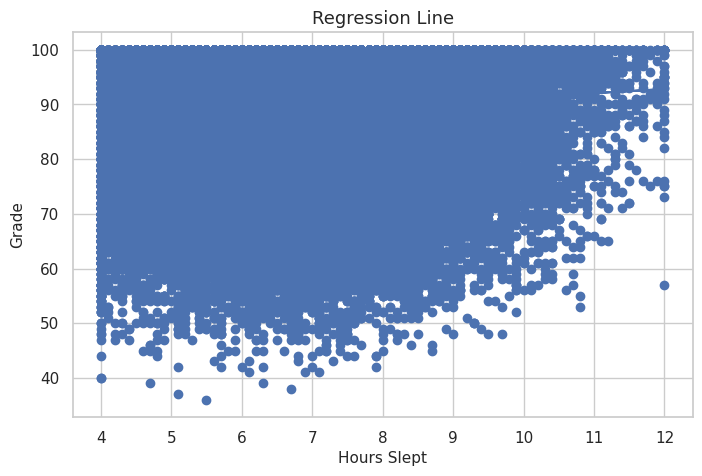

In [49]:
plt.scatter(Xsimple, y)
plt.plot(Xsimple, m_simple.predict(Xsimple))
plt.xlabel("Hours Slept")
plt.ylabel("Grade")
plt.title("Regression Line")
plt.show()